# YOLO Model Training for ROad Violence Detection:

In [ ]:
!nvidia-smi

Wed Nov 26 09:25:28 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   51C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Mount Dataset from Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip images to a custom folder
!unzip -q "/content/drive/MyDrive/Research/Road Violence Dataset YOLO.zip" -d "/content/custom_data"
# !unzip -q "/content/Road Violence Dataset YOLO.zip" -d "/content/custom_data"

Automatically create the folder structure required for training and randomly split 90% of the dataset for training and other 10% for validation dataset.

In [ ]:
!wget -O /content/train_val_split.py https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-models/refs/heads/main/utils/train_val_split.py

# TODO: Improve robustness of train_val_spliit.py script so it can handle nested data folders, etc
!python train_val_split.py --datapath="/content/custom_data" --train_pct=0.9

--2025-11-26 09:26:08--  https://raw.githubusercontent.com/EdjeElectronics/Train-and-Deploy-YOLO-models/refs/heads/main/utils/train_val_split.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3203 (3.1K) [text/plain]
Saving to: ‘/content/train_val_split.py’

/content/train_val_ 100%[===================>]   3.13K  --.-KB/s    in 0s      

2025-11-26 09:26:08 (49.6 MB/s) - ‘/content/train_val_split.py’ saved [3203/3203]

Created folder at /content/data/train/images.
Created folder at /content/data/train/labels.
Created folder at /content/data/validation/images.
Created folder at /content/data/validation/labels.
Number of image files: 162
Number of annotation files: 162
Images moving to train: 145
Images moving to validation: 17


## Install Requirements

Installs Python library Ultralytics library and YOLO. official package for YOLO models and their versions and other Training, validation, and inference tools

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 27.6 MB/s eta 0:00:00


## Configure Training

data.yaml file contrains locations of train and validation datasets and defines models classes.

In [ ]:
# data.yaml file contents
print("File contents")
!cat /content/data/data.yaml

File contents
path: /content/data
train: train/images
val: validation/images
nc: 4
names:
- gun
- knife
- stick
- weapon


If not above, this below automatically creates the data.yaml file

In [ ]:
import yaml
import os

def create_data_yaml(path_to_classes_txt, path_to_data_yaml):

  # Read classes.txt to get class names
  if not os.path.exists(path_to_classes_txt):
    print(f'classes.txt file not found! please create a classes.txt labelmap and move it to {path_to_classes_txt}')
    return
  with open(path_to_classes_txt, 'r') as f:
    classes = []
    for line in f.readlines():
      if len(line.strip()) == 0: continue
      classes.append(line.strip())
  number_of_classes = len(classes)

  # Create data dictionary
  data = {
      'path': '/content/data',
      'train': 'train/images',
      'val': 'validation/images',
      'nc': number_of_classes,
      'names': classes
  }

  # Write data to YAML file
  with open(path_to_data_yaml, 'w') as f:
    yaml.dump(data, f, sort_keys=False)
  print(f'Created config file at {path_to_data_yaml}')

  return

# Define path to classes.txt and run function
path_to_classes_txt = '/content/custom_data/classes.txt'
path_to_data_yaml = '/content/data/data.yaml'

create_data_yaml(path_to_classes_txt, path_to_data_yaml)

print('\nFile contents:\n')
!cat /content/data/data.yaml

Created config file at /content/data/data.yaml

File contents:

path: /content/data
train: train/images
val: validation/images
nc: 4
names:
- gun
- knife
- stick
- weapon


## Check Dataset

Loads a few images from the dataset and draws the bounding boxes from the label files so it visually check if almost all annotations are correct.

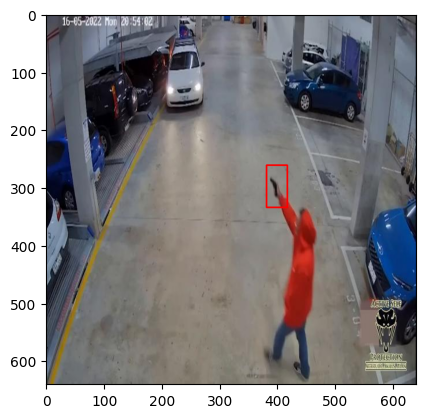

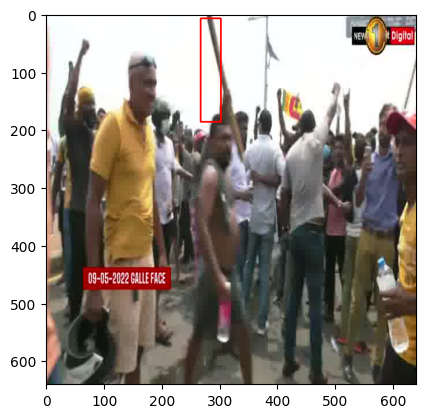

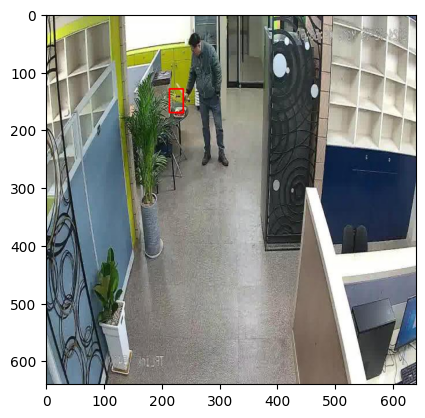

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = 'data/train/images'
label_path = 'data/train/labels'

img_files = os.listdir(img_path)[:3]  # show 3 images
# for f in img_files:
#     img = cv2.imread(os.path.join(img_path, f))
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     plt.imshow(img)
#     plt.show()

for f in img_files:
    img = cv2.imread(os.path.join(img_path, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Read corresponding label file
    label_file = os.path.join(label_path, f.replace('.jpg', '.txt'))
    if os.path.exists(label_file):
        with open(label_file) as lf:
            for line in lf:
                cls, x_center, y_center, w, h = map(float, line.strip().split())
                h_img, w_img, _ = img.shape
                # Convert YOLO bbox to pixel coordinates
                x1 = int((x_center - w/2) * w_img)
                y1 = int((y_center - h/2) * h_img)
                x2 = int((x_center + w/2) * w_img)
                y2 = int((y_center + h/2) * h_img)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.imshow(img)
    plt.show()


## Train Model

**Model Architecture:** YOLO8s </br>
**Number of epochs:** if more than 200 - 40, if less than 200 - 60 </br>
**Resolution:** 640x640

After training model weights will be saved in runs/detect/train/weights/... folders


In [ ]:
# Run training
!yolo detect train data=/content/data/data.yaml model=yolov8s.pt epochs=60 imgsz=640

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False,

In [ ]:
# saves to google drive
!cp -r /content/runs/detect/train2 /content/drive/MyDrive/yolo_results

## Test Model

Run on Validation images to test if model works as expected. Results are saved to /content/runs/detect/predict/


In [ ]:
!yolo detect predict source='/content/data/validation/images' model='/content/runs/detect/train/weights/best.pt' save=True

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs

image 1/17 /content/data/validation/images/058bf05a-gun_28.jpg: 640x640 1 gun, 16.3ms
image 2/17 /content/data/validation/images/14aeae77-gun_20.jpg: 640x640 (no detections), 16.2ms
image 3/17 /content/data/validation/images/2ac7f482-gun_60.jpg: 640x640 (no detections), 16.2ms
image 4/17 /content/data/validation/images/4c5cdcde-gun_26.jpg: 640x640 1 gun, 16.2ms
image 5/17 /content/data/validation/images/565c3755-gun_49.jpg: 640x640 1 gun, 16.2ms
image 6/17 /content/data/validation/images/5b4b1961-knife_30.jpg: 640x640 (no detections), 16.2ms
image 7/17 /content/data/validation/images/6275b0d1-vobject_40.jpg: 640x640 2 sticks, 16.2ms
image 8/17 /content/data/validation/images/6d6389e5-knife_37.jpg: 640x640 (no detections), 44.5ms
image 9/17 /content/data/validation/images/720e4736-vobject_43.jpg: 640x640 (no detections), 40

Evaluate performance using mAP, precision, recall




In [ ]:
!yolo val model='/content/runs/detect/train/weights/best.pt' data='/content/data/data.yaml' imgsz=640

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2128.3±637.1 MB/s, size: 51.8 KB)
val: Scanning /content/data/validation/labels.cache... 17 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 17/17 341.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.2it/s 0.6s
                   all         17         23      0.842      0.333      0.402      0.193
                   gun          6          6      0.985      0.667      0.842      0.397
                 knife          4          4      0.487        0.5      0.522      0.308
                 stick          6         12      0.896      0.167      0.243     0.0675
                weapon          1          1          1          0          0          0
Speed: 4.9ms preprocess, 20.5ms inference, 0.0ms 

Display results for the first 10 images (using IPython for quick display)

In [ ]:
import glob
from IPython.display import Image, display
for image_path in glob.glob(f'/content/runs/detect/predict/*.jpg')[:10]:
  display(Image(filename=image_path, height=400))
  print('\n')

Display results for the first 3 images (using OpenCV and Matplotlib for preview with image processing control)


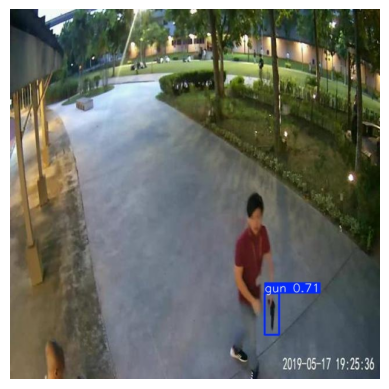

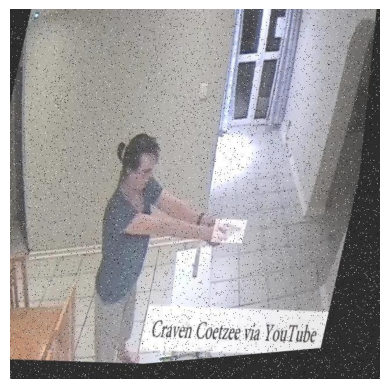

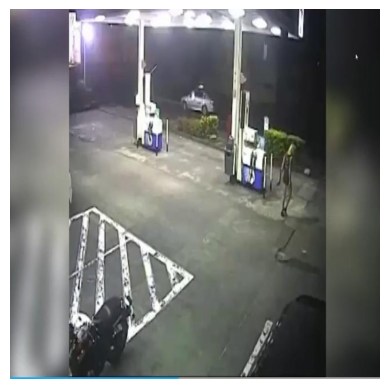

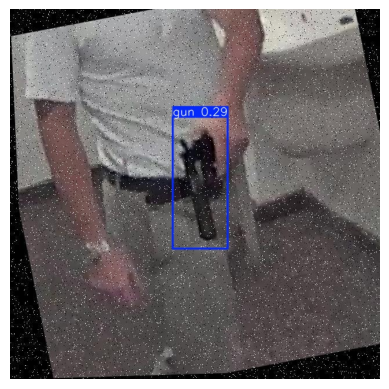

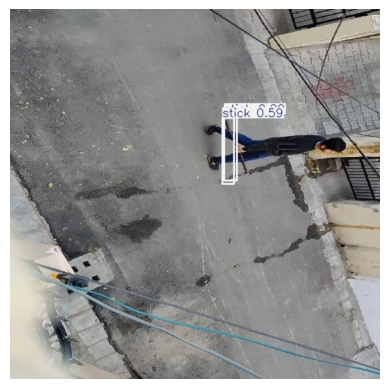

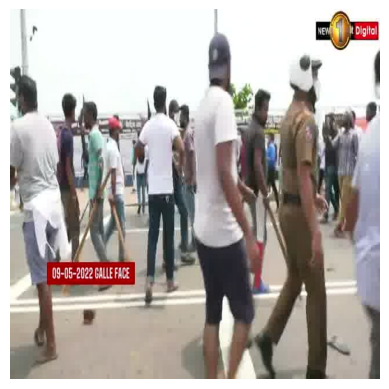

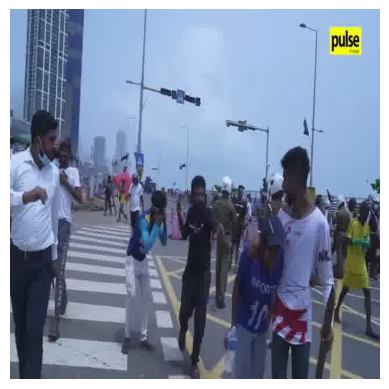

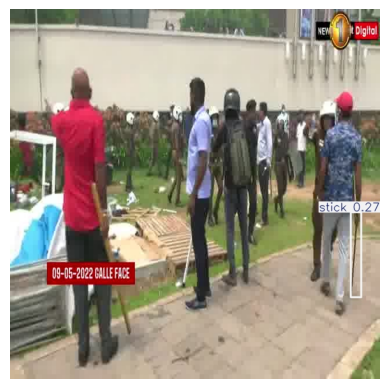

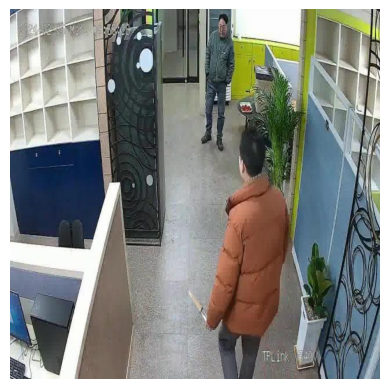

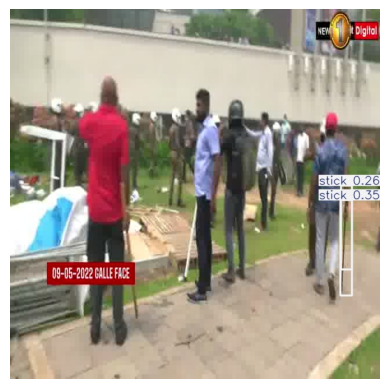

In [ ]:
predicted_images = os.listdir('/content/runs/detect/predict')[:10]
for img_file in predicted_images:
    img = cv2.imread(os.path.join('/content/runs/detect/predict', img_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

## Download YOLO model

Create 'my_model' folder to store model weights and train results, and zip into my_model.zip

In [ ]:
# Create 'my_model' folder and save model weights and train results
!mkdir /content/my_model
!cp /content/runs/detect/train/weights/best.pt /content/my_model/my_model.path
!cp -r /content/runs/detect/train /content/my_model

# Zip into my_model.zip
%cd my_model
!zip /content/my_model.zip my_model.pt
!zip -r /content/my_model.zip train
%cd /content

/content/my_model2
	zip warning: name not matched: my_model2.pt

zip error: Nothing to do! (/content/my_model2.zip)
  adding: train/ (stored 0%)
  adding: train/train_batch500.jpg (deflated 3%)
  adding: train/train_batch2.jpg (deflated 1%)
  adding: train/BoxPR_curve.png (deflated 18%)
  adding: train/train_batch502.jpg (deflated 6%)
  adding: train/weights/ (stored 0%)
  adding: train/weights/last.pt (deflated 8%)
  adding: train/weights/best.pt (deflated 8%)
  adding: train/args.yaml (deflated 53%)
  adding: train/BoxR_curve.png (deflated 16%)
  adding: train/results.png (deflated 5%)
  adding: train/train_batch501.jpg (deflated 9%)
  adding: train/results.csv (deflated 60%)
  adding: train/confusion_matrix.png (deflated 34%)
  adding: train/BoxP_curve.png (deflated 13%)
  adding: train/val_batch0_labels.jpg (deflated 6%)
  adding: train/BoxF1_curve.png (deflated 12%)
  adding: train/train_batch1.jpg (deflated 2%)
  adding: train/labels.jpg (deflated 37%)
  adding: train/train_batch

In [ ]:
# zip data folder
!zip -r data.zip /content/data

# zip runs folder
!zip -r runs.zip /content/runs

updating: content/data/ (stored 0%)
updating: content/data/validation/ (stored 0%)
updating: content/data/validation/images/ (stored 0%)
updating: content/data/validation/images/e618e790-gun_39.jpg (deflated 0%)
updating: content/data/validation/images/2ac7f482-gun_60.jpg (deflated 2%)
updating: content/data/validation/images/6d6389e5-knife_37.jpg (deflated 2%)
updating: content/data/validation/images/565c3755-gun_49.jpg (deflated 2%)
updating: content/data/validation/images/6275b0d1-vobject_40.jpg (deflated 0%)
updating: content/data/validation/images/7733fafb-vobject_12.jpg (deflated 2%)
updating: content/data/validation/images/7d899db7-vobject_32.jpg (deflated 1%)
updating: content/data/validation/images/921ffe12-vobject_15.jpg (deflated 0%)
updating: content/data/validation/images/5b4b1961-knife_30.jpg (deflated 0%)
updating: content/data/validation/images/9b0dac61-vobject_14.jpg (stored 0%)
updating: content/data/validation/images/e567939e-knife_28.jpg (deflated 0%)
updating: cont

## Running Locally

In [ ]:
## download python script for running in local
# curl -o yolo_detect.py https://www.ejtech.io/code/yolo_detect.py

## open usb camera and run the model
# python yolo_detect.py --model my_model.pt --source usb0 --resolution 1280x720